In [11]:
from datetime import date, timedelta

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(7)


# Synthetic Time Series from Decomposition

The observed series is built as an additive decomposition:

$$y_t = T_t + S_t + C_t + R_t,$$

where $T_t$ is trend, $S_t$ is seasonality, $C_t$ is a slower cycle, and $R_t$ is residual noise.


In [12]:
def generate_series(
    periods: int = 3 * 365,
    start: str = "2021-01-01",
    noise_scale: float = 1.4,
) -> dict[str, np.ndarray]:
    """Generate a daily additive time series and expose every component."""
    if periods <= 0:
        raise ValueError("periods must be positive")
    if noise_scale < 0:
        raise ValueError("noise_scale must be non-negative")

    first_day = date.fromisoformat(start)
    dates = np.array([first_day + timedelta(days=offset) for offset in range(periods)])
    t = np.arange(periods, dtype=float)

    trend = 35 + 0.028 * t + 5 / (1 + np.exp(-(t - 650) / 45))
    seasonality = 8 * np.sin(2 * np.pi * t / 365.25 - np.pi / 6)
    cycle = 3.0 * np.sin(2 * np.pi * t / (1.7 * 365.25) + 0.8)

    residual = rng.normal(loc=0.0, scale=noise_scale, size=periods)
    observed = trend + seasonality + cycle + residual

    return {
        "date": dates,
        "observed": observed,
        "trend": trend,
        "seasonality": seasonality,
        "cycle": cycle,
        "residual": residual,
    }


In [13]:
components = generate_series()
component_columns = [
    "trend",
    "seasonality",
    "cycle",
    "residual",
]

reconstructed = sum(components[column] for column in component_columns)
np.testing.assert_allclose(components["observed"], reconstructed)

preview_rows = []
for row in range(5):
    preview_rows.append(
        {
            "date": components["date"][row].isoformat(),
            **{column: round(float(components[column][row]), 2) for column in ["observed", *component_columns]},
        }
    )

preview_rows


[{'date': '2021-01-01',
  'observed': 33.15,
  'trend': 35.0,
  'seasonality': -4.0,
  'cycle': 2.15,
  'residual': 0.0},
 {'date': '2021-01-02',
  'observed': 33.74,
  'trend': 35.03,
  'seasonality': -3.88,
  'cycle': 2.17,
  'residual': 0.42},
 {'date': '2021-01-03',
  'observed': 33.11,
  'trend': 35.06,
  'seasonality': -3.76,
  'cycle': 2.19,
  'residual': -0.38},
 {'date': '2021-01-04',
  'observed': 32.41,
  'trend': 35.08,
  'seasonality': -3.64,
  'cycle': 2.21,
  'residual': -1.25},
 {'date': '2021-01-05',
  'observed': 33.2,
  'trend': 35.11,
  'seasonality': -3.51,
  'cycle': 2.23,
  'residual': -0.64}]

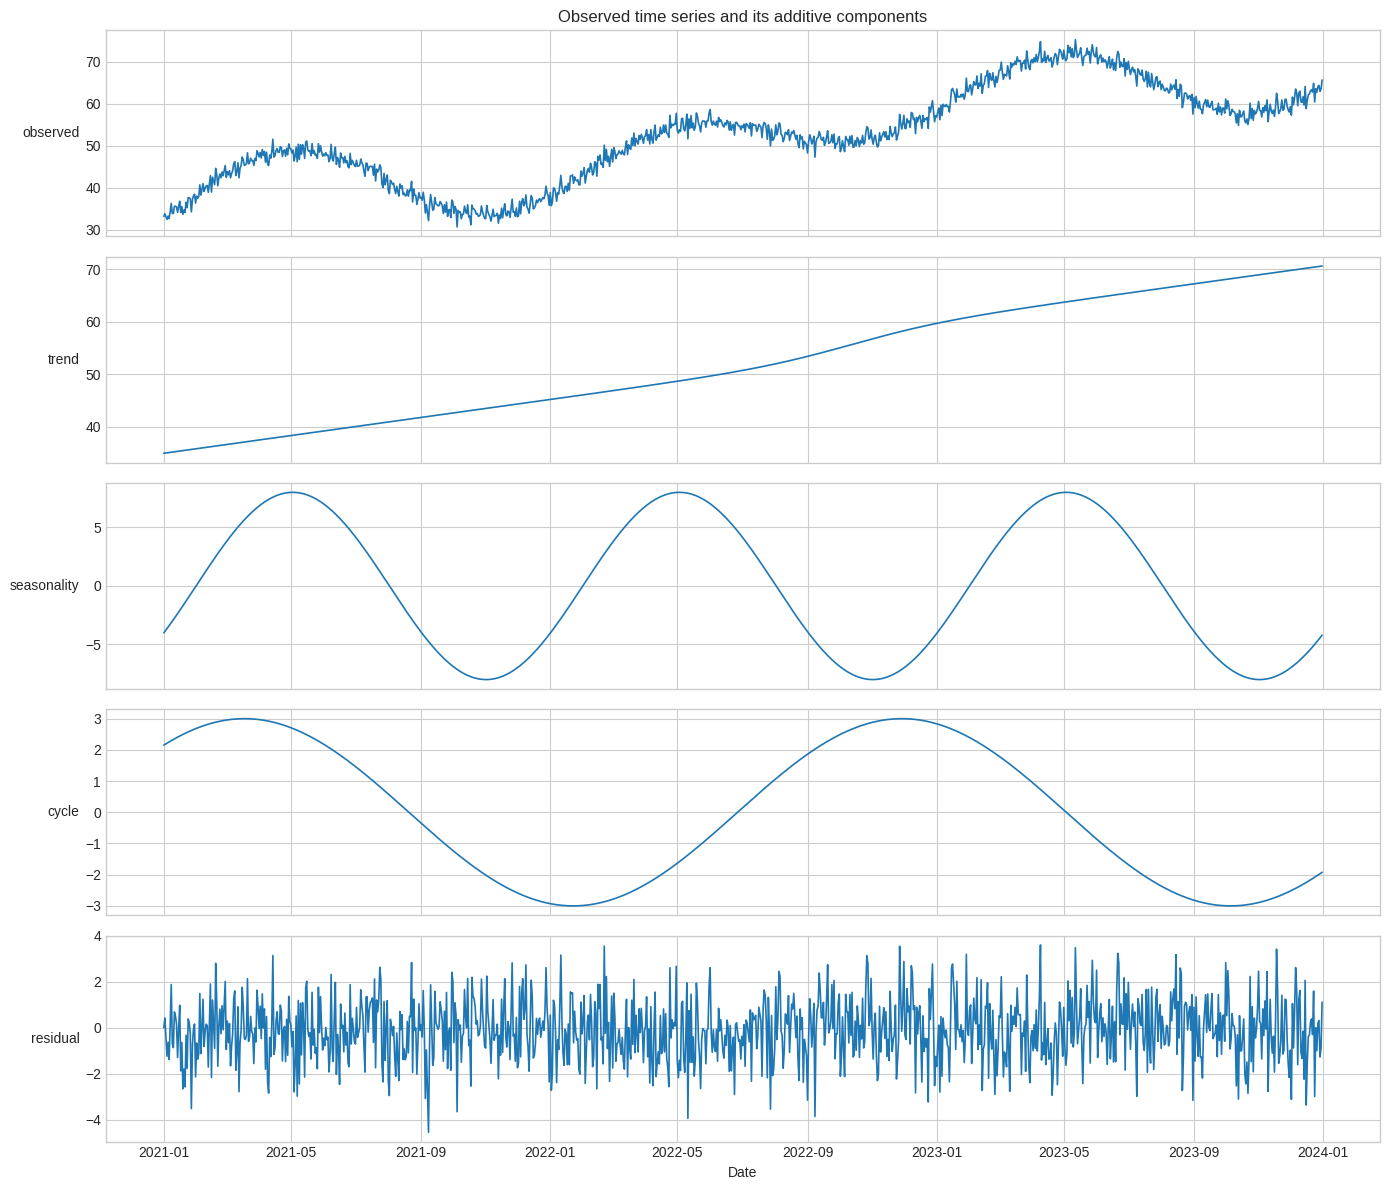

In [14]:
plot_columns = ["observed", *component_columns]
fig, axes = plt.subplots(len(plot_columns), 1, figsize=(14, 12), sharex=True)

for ax, column in zip(axes, plot_columns):
    ax.plot(components["date"], components[column], linewidth=1.2)
    ax.set_ylabel(column.replace("_", "\n"), rotation=0, ha="right", va="center")

axes[0].set_title("Observed time series and its additive components")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


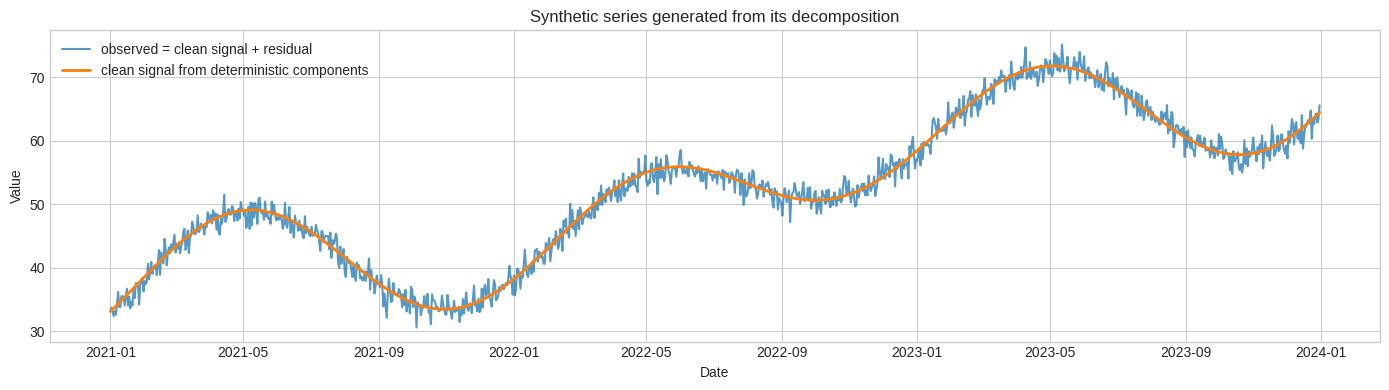

In [15]:
deterministic_columns = [column for column in component_columns if column != "residual"]
clean_signal = sum(components[column] for column in deterministic_columns)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(components["date"], components["observed"], label="observed = clean signal + residual", alpha=0.75)
ax.plot(components["date"], clean_signal, label="clean signal from deterministic components", linewidth=2)
ax.set_title("Synthetic series generated from its decomposition")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()


## ACF-Based Window Length Selection

Before training an RNN, LSTM, or GRU, the input window should cover the lags that still carry useful dependence. The autocorrelation function (ACF) gives a simple criterion:

- estimate the lag correlation of the observed series,
- use the approximate white-noise confidence band $\pm 1.96 / \sqrt{n}$,
- choose the first lag before the ACF stays inside that band for several consecutive lags,
- keep a significant seasonal peak when one appears before the maximum allowed window.


In [16]:
def autocorrelation(series: np.ndarray, max_lag: int) -> np.ndarray:
    """Compute the sample ACF from lag 0 through max_lag."""
    values = np.asarray(series, dtype=float)
    if values.ndim != 1:
        raise ValueError("series must be one-dimensional")
    if len(values) < 2:
        raise ValueError("series must contain at least two observations")
    if max_lag < 1:
        raise ValueError("max_lag must be at least 1")
    if max_lag >= len(values):
        raise ValueError("max_lag must be smaller than the series length")

    centered = values - values.mean()
    denominator = np.dot(centered, centered)
    if denominator == 0:
        raise ValueError("ACF is undefined for a constant series")

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0
    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(centered[:-lag], centered[lag:]) / denominator
    return acf


def find_first_sustained_insignificant_lag(
    acf: np.ndarray,
    confidence_limit: float,
    consecutive_lags: int,
) -> int | None:
    """Find when the ACF first becomes statistically negligible for a run of lags."""
    if consecutive_lags < 1:
        raise ValueError("consecutive_lags must be positive")

    insignificant = np.abs(acf[1:]) <= confidence_limit
    for start in range(0, len(insignificant) - consecutive_lags + 1):
        if insignificant[start : start + consecutive_lags].all():
            return start + 1
    return None


def find_significant_acf_peaks(
    acf: np.ndarray,
    confidence_limit: float,
    min_lag: int = 2,
) -> list[int]:
    """Return positive local ACF peaks that exceed the confidence band."""
    peaks = []
    for lag in range(max(1, min_lag), len(acf) - 1):
        is_local_peak = acf[lag] >= acf[lag - 1] and acf[lag] >= acf[lag + 1]
        if is_local_peak and acf[lag] > confidence_limit:
            peaks.append(lag)

    final_lag = len(acf) - 1
    if final_lag >= min_lag and acf[final_lag] >= acf[final_lag - 1] and acf[final_lag] > confidence_limit:
        peaks.append(final_lag)
    return peaks


In [17]:
def choose_window_length_from_acf(
    series: np.ndarray,
    max_lag: int | None = None,
    max_window: int = 365,
    min_window: int = 7,
    consecutive_insignificant_lags: int = 14,
) -> dict[str, object]:
    """Choose a sequence-model window length using ACF significance criteria."""
    values = np.asarray(series, dtype=float)
    if max_window < min_window:
        raise ValueError("max_window must be greater than or equal to min_window")
    if max_lag is None:
        max_lag = min(max_window, len(values) // 3)
    max_lag = min(max_lag, max_window, len(values) - 1)

    acf = autocorrelation(values, max_lag=max_lag)
    confidence_limit = 1.96 / np.sqrt(len(values))
    first_insignificant_lag = find_first_sustained_insignificant_lag(
        acf=acf,
        confidence_limit=confidence_limit,
        consecutive_lags=consecutive_insignificant_lags,
    )
    if first_insignificant_lag is None:
        memory_horizon = max_lag
        reason = "ACF remains significant through the maximum candidate lag"
    else:
        memory_horizon = max(min_window, first_insignificant_lag - 1)
        reason = "short-memory horizon before sustained insignificant autocorrelation"

    peaks = find_significant_acf_peaks(acf, confidence_limit=confidence_limit, min_lag=min_window)
    seasonal_lag = max(peaks, key=lambda lag: acf[lag], default=None)

    selected_window = memory_horizon
    if seasonal_lag is not None and seasonal_lag > selected_window:
        selected_window = seasonal_lag
        reason = "largest requirement after keeping the strongest significant seasonal ACF peak"

    selected_window = int(np.clip(selected_window, min_window, max_window))
    return {
        "window_length": selected_window,
        "acf": acf,
        "confidence_limit": confidence_limit,
        "first_insignificant_lag": first_insignificant_lag,
        "memory_horizon": memory_horizon,
        "seasonal_lag": seasonal_lag,
        "significant_peaks": peaks,
        "reason": reason,
    }


window_selection = choose_window_length_from_acf(components["observed"])
window_selection_summary = {
    "window_length": window_selection["window_length"],
    "confidence_limit": round(float(window_selection["confidence_limit"]), 3),
    "first_insignificant_lag": window_selection["first_insignificant_lag"],
    "memory_horizon": window_selection["memory_horizon"],
    "seasonal_lag": window_selection["seasonal_lag"],
    "reason": window_selection["reason"],
}

window_selection_summary


{'window_length': 365,
 'confidence_limit': 0.059,
 'first_insignificant_lag': None,
 'memory_horizon': 365,
 'seasonal_lag': None,
 'reason': 'ACF remains significant through the maximum candidate lag'}

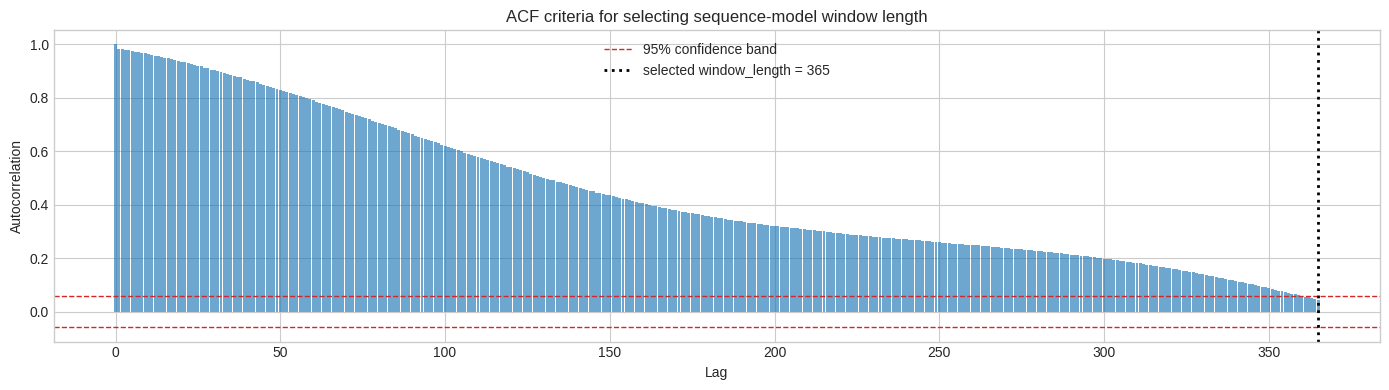

In [18]:
acf = window_selection["acf"]
lags = np.arange(len(acf))
confidence_limit = window_selection["confidence_limit"]
window_length = window_selection["window_length"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(lags, acf, width=0.9, color="tab:blue", alpha=0.65)
ax.axhline(confidence_limit, color="tab:red", linestyle="--", linewidth=1, label="95% confidence band")
ax.axhline(-confidence_limit, color="tab:red", linestyle="--", linewidth=1)
ax.axvline(window_length, color="black", linestyle=":", linewidth=2, label=f"selected window_length = {window_length}")

seasonal_lag = window_selection["seasonal_lag"]
if seasonal_lag is not None:
    ax.scatter([seasonal_lag], [acf[seasonal_lag]], color="tab:orange", zorder=3, label=f"seasonal peak = {seasonal_lag}")

ax.set_title("ACF criteria for selecting sequence-model window length")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Just drafting...
series = ???
series = (series - series.min()) / series.max()  # Normalize to [0, 1]

window_length = ???

# Keras models
# train a LSTM, GRU, RNN and a classic Dense network to predict the next value from the previous window_length values, then compare their performance